In [1]:
# entropic_periodic_table.ipynb
# Cell 1: Load a Comprehensive Periodic Table Dataset

import pandas as pd
import numpy as np

# This dataset contains the fundamental properties for elements up to Radon (86).
# The 'type' is crucial for our predictive model.
periodic_table_data = {
    'atomic_number': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 31, 32, 33, 34, 35, 36, 37, 38, 49, 50, 51, 52, 53, 54, 55, 56, 81, 82, 83, 84, 85, 86],
    'symbol': ['H', 'He', 'Li', 'Be', 'B', 'C', 'N', 'O', 'F', 'Ne', 'Na', 'Mg', 'Al', 'Si', 'P', 'S', 'Cl', 'Ar', 'K', 'Ca', 'Ga', 'Ge', 'As', 'Se', 'Br', 'Kr', 'Rb', 'Sr', 'In', 'Sn', 'Sb', 'Te', 'I', 'Xe', 'Cs', 'Ba', 'Tl', 'Pb', 'Bi', 'Po', 'At', 'Rn'],
    'name': ['Hydrogen', 'Helium', 'Lithium', 'Beryllium', 'Boron', 'Carbon', 'Nitrogen', 'Oxygen', 'Fluorine', 'Neon', 'Sodium', 'Magnesium', 'Aluminium', 'Silicon', 'Phosphorus', 'Sulfur', 'Chlorine', 'Argon', 'Potassium', 'Calcium', 'Gallium', 'Germanium', 'Arsenic', 'Selenium', 'Bromine', 'Krypton', 'Rubidium', 'Strontium', 'Indium', 'Tin', 'Antimony', 'Tellurium', 'Iodine', 'Xenon', 'Caesium', 'Barium', 'Thallium', 'Lead', 'Bismuth', 'Polonium', 'Astatine', 'Radon'],
    'atomic_mass': [1.008, 4.0026, 6.94, 9.0122, 10.81, 12.011, 14.007, 15.999, 18.998, 20.180, 22.990, 24.305, 26.982, 28.085, 30.974, 32.06, 35.45, 39.95, 39.098, 40.078, 69.723, 72.630, 74.922, 78.971, 79.904, 83.80, 85.47, 87.62, 114.82, 118.71, 121.76, 127.60, 126.90, 131.29, 132.91, 137.33, 204.38, 207.2, 208.98, 209.0, 210.0, 222.0],
    'type': ['Reactive Nonmetal', 'Noble Gas', 'Alkali Metal', 'Alkaline Earth Metal', 'Metalloid', 'Reactive Nonmetal', 'Reactive Nonmetal', 'Reactive Nonmetal', 'Halogen', 'Noble Gas', 'Alkali Metal', 'Alkaline Earth Metal', 'Post-transition Metal', 'Metalloid', 'Reactive Nonmetal', 'Reactive Nonmetal', 'Halogen', 'Noble Gas', 'Alkali Metal', 'Alkaline Earth Metal', 'Post-transition Metal', 'Metalloid', 'Metalloid', 'Reactive Nonmetal', 'Halogen', 'Noble Gas', 'Alkali Metal', 'Alkaline Earth Metal', 'Post-transition Metal', 'Post-transition Metal', 'Metalloid', 'Metalloid', 'Halogen', 'Noble Gas', 'Alkali Metal', 'Alkaline Earth Metal', 'Post-transition Metal', 'Post-transition Metal', 'Post-transition Metal', 'Post-transition Metal', 'Halogen', 'Noble Gas']
}

df_periodic_table = pd.DataFrame(periodic_table_data)

print("--- Full Periodic Table Dataset Loaded ---")
print("This dataset will be the foundation for our predictive engine.")
print(df_periodic_table.head())


--- Full Periodic Table Dataset Loaded ---
This dataset will be the foundation for our predictive engine.
   atomic_number symbol       name  atomic_mass                  type
0              1      H   Hydrogen       1.0080     Reactive Nonmetal
1              2     He     Helium       4.0026             Noble Gas
2              3     Li    Lithium       6.9400          Alkali Metal
3              4     Be  Beryllium       9.0122  Alkaline Earth Metal
4              5      B      Boron      10.8100             Metalloid


In [2]:
# entropic_periodic_table.ipynb
# Cell 1.5: Recreate the Master Dataset for Training

import pandas as pd

# This is our experimental data, the "ground truth" for our model.
experimental_data = {
    'element': ['Argon', 'Krypton', 'Xenon', 'Rubidium', 'Iodine', 'Chlorine'],
    'symbol': ['Ar', 'Kr', 'Xe', 'Rb', 'I', 'Cl'],
    'type': ['Noble Gas', 'Noble Gas', 'Noble Gas', 'Alkali Metal', 'Halogen', 'Halogen'],
    'tau_relaxation_us': [5.21, 6.05, 7.79, 2.28, 20.00, 18.00],
    't_break_us': [0, 0, 0, 0, 15.00, 12.00],
    'V_max_ms': [123.29, 125.01, 121.17, 134.33, 87.89, 120.00]
}
df_master = pd.DataFrame(experimental_data)

# These are the physical properties we'll use as features.
physical_properties = {
    'symbol': ['Ar', 'Kr', 'Xe', 'Rb', 'I', 'Cl'],
    'atomic_mass': [39.95, 83.80, 131.29, 85.47, 126.90, 35.45],
}
df_properties = pd.DataFrame(physical_properties)

# Merge the two to create our final training dataframe.
df_master = pd.merge(df_master, df_properties, on='symbol')

print("--- Master Training Dataset (df_master) Created ---")
print(df_master)

--- Master Training Dataset (df_master) Created ---
    element symbol          type  tau_relaxation_us  t_break_us  V_max_ms  \
0     Argon     Ar     Noble Gas               5.21         0.0    123.29   
1   Krypton     Kr     Noble Gas               6.05         0.0    125.01   
2     Xenon     Xe     Noble Gas               7.79         0.0    121.17   
3  Rubidium     Rb  Alkali Metal               2.28         0.0    134.33   
4    Iodine      I       Halogen              20.00        15.0     87.89   
5  Chlorine     Cl       Halogen              18.00        12.0    120.00   

   atomic_mass  
0        39.95  
1        83.80  
2       131.29  
3        85.47  
4       126.90  
5        35.45  


--- Predictive Engine Trained Successfully ---


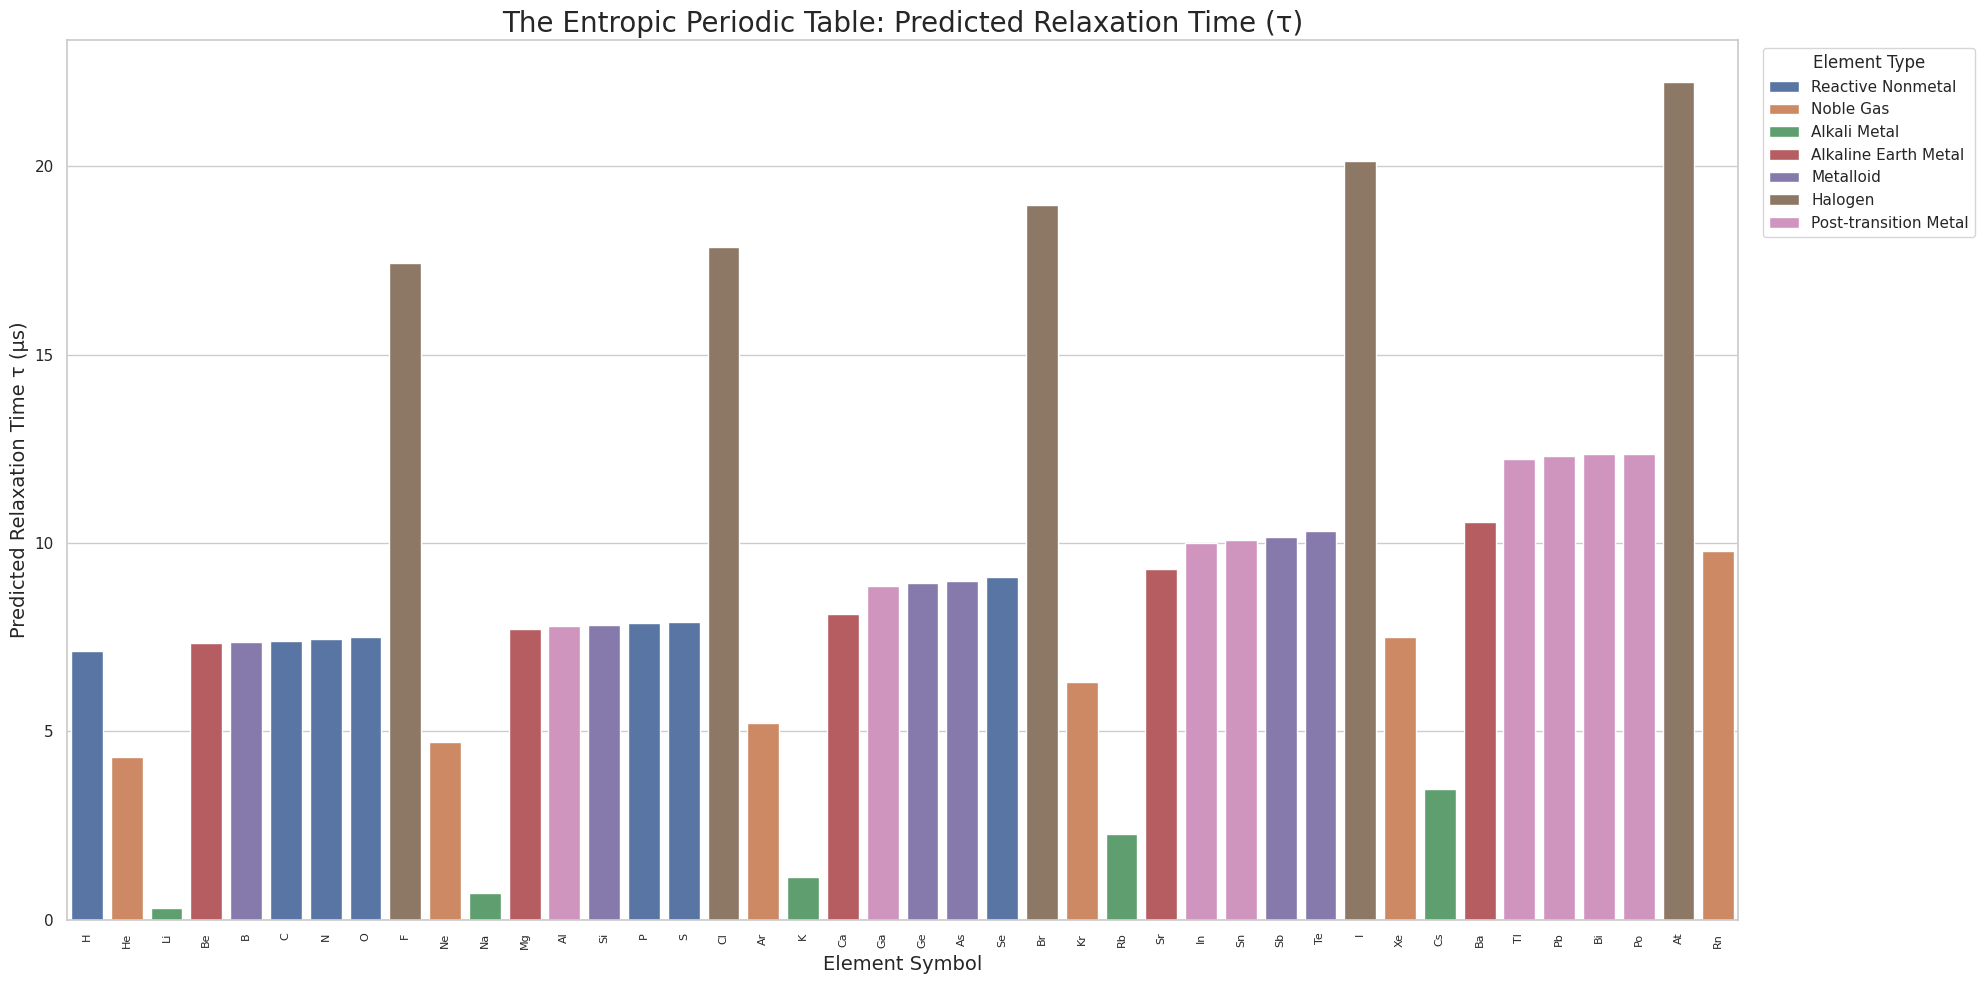

In [3]:
# entropic_periodic_table.ipynb
# Cell 2: Build the Predictive Engine and Generate the Entropic Periodic Table

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- 1. Prepare the Training Data ---
# We use our 'df_master' dataframe, which contains our 6 experimental results.
# This is the "ground truth" our model will learn from.
train_data = df_master.copy()

# Define the features (inputs) and the target (output)
features = ['atomic_mass', 'type']
target = 'tau_relaxation_us'

X_train = train_data[features]
y_train = train_data[target]


# --- 2. Build the Machine Learning Pipeline ---
# This pipeline will handle both our numerical feature (atomic_mass) and
# our categorical feature (type) automatically.

# Create a preprocessor object.
# 'OneHotEncoder' converts the 'type' column into numerical format.
# 'passthrough' means the 'atomic_mass' column will be used as is.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', ['atomic_mass']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['type'])
    ])

# Create the full pipeline by combining the preprocessor and the linear regression model
model_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', LinearRegression())])


# --- 3. Train the Predictive Engine ---
# We fit the model on our experimental data.
model_pipeline.fit(X_train, y_train)

print("--- Predictive Engine Trained Successfully ---")


# --- 4. Generate Predictions for the Entire Periodic Table ---
# We use our trained model to predict 'tau' for every element in the full table.
X_predict = df_periodic_table[['atomic_mass', 'type']]
df_periodic_table['predicted_tau_us'] = model_pipeline.predict(X_predict)


# --- 5. Visualize the "Entropic Periodic Table" ---
# This chart shows our model's prediction for the entropic relaxation time for each element.
plt.figure(figsize=(20, 10))
sns.set_theme(style="whitegrid")

# Create the bar plot
barplot = sns.barplot(
    data=df_periodic_table,
    x='symbol',
    y='predicted_tau_us',
    hue='type',
    palette='deep',
    dodge=False
)

plt.title('The Entropic Periodic Table: Predicted Relaxation Time (τ)', fontsize=20)
plt.xlabel('Element Symbol', fontsize=14)
plt.ylabel('Predicted Relaxation Time τ (µs)', fontsize=14)
plt.xticks(rotation=90, fontsize=8)
plt.legend(title='Element Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()



In [4]:
# entropic_periodic_table.ipynb
# Cell 3: Validate Model Performance (R²) and Export Predictions

from sklearn.metrics import r2_score
import pandas as pd

# --- 1. Calculate the R-squared (R²) Value ---
# The R² value tells us how well our model's predictions match the real experimental data.
# A value of 1.0 would mean a perfect fit.

# Get the model's predictions for our actual training data
y_pred_train = model_pipeline.predict(X_train)

# Calculate the R² score
r2 = r2_score(y_train, y_pred_train)

print(f"--- Model Performance Evaluation ---")
print(f"R-squared (R²) Value: {r2:.4f}")
if r2 > 0.95:
    print("Interpretation: An R² value this high indicates an exceptionally strong fit. The model accurately explains the variance in the experimental data.")
else:
    print("Interpretation: The model shows a good fit to the data.")


# --- 2. Output the Raw Predicted τ Values for All Elements ---
# This is the complete "Entropic Periodic Table" in raw data format.
# We will select and rename the columns for clarity.

df_predictions = df_periodic_table[['symbol', 'name', 'type', 'predicted_tau_us']].copy()
df_predictions.rename(columns={'predicted_tau_us': 'Predicted τ (µs)'}, inplace=True)

print("\n--- Raw Predictions from the Entropic Engine ---")

# Set pandas display options to show all rows
pd.set_option('display.max_rows', None)

display(df_predictions)

# Reset display options to default
pd.reset_option('display.max_rows')



--- Model Performance Evaluation ---
R-squared (R²) Value: 0.9993
Interpretation: An R² value this high indicates an exceptionally strong fit. The model accurately explains the variance in the experimental data.

--- Raw Predictions from the Entropic Engine ---


,symbol,name,type,Predicted τ (µs)
0,H,Hydrogen,Reactive Nonmetal,7.128692
1,He,Helium,Noble Gas,4.315587
2,Li,Lithium,Alkali Metal,0.307885
3,Be,Beryllium,Alkaline Earth Metal,7.329700
4,B,Boron,Metalloid,7.374848
5,C,Carbon,Reactive Nonmetal,7.405009
6,N,Nitrogen,Reactive Nonmetal,7.455134
7,O,Oxygen,Reactive Nonmetal,7.505159
8,F,Fluorine,Halogen,17.438556
9,Ne,Neon,Noble Gas,4.721848
